


Data from Garrido et al. J Neurophysiol 2009 (doi:10.1152/jn.90291.2008)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- analysis parameters ---
fs = 512                     # sampling rate (Hz)
notch_freq, notch_q = 50, 30 # mains noise notch filter
band_low, band_high = 4, 40  # band-pass range (Hz)
electrode_cols = range(1, 9) # columns 1-8 hold the 8 EEG channels


os.getcwd()
# si la fin du path contient scripts, on remonte d'un niveau
if os.getcwd().endswith('scripts'):
    os.chdir('..')
    print(os.getcwd())
 
    

d:\DATA\Projets\M1_EEG_Project


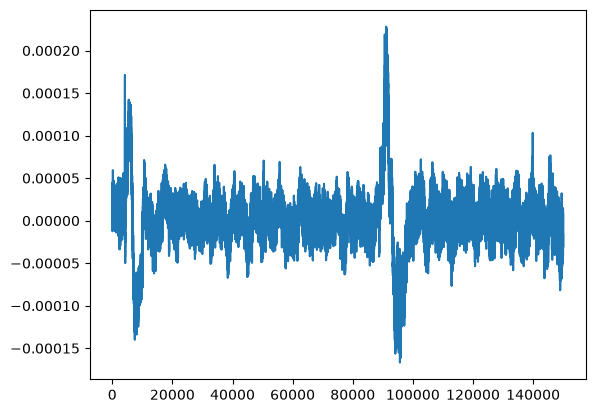

In [2]:
# get data from csv file
data = pd.read_csv('data/EEG_ses_raw.csv', sep='\t', header=None)

# example trace
plt.plot(data[7])


In [3]:
from scipy.signal import iirnotch, filtfilt, butter

data_filtered = []

for electrode in electrode_cols:
    raw = data[electrode].to_numpy()

    b, a = iirnotch(notch_freq, notch_q, fs)
    notched = filtfilt(b, a, raw)

    b, a = butter(4, [band_low / (fs / 2), band_high / (fs / 2)], btype='band')
    bandpassed = filtfilt(b, a, notched)

    data_filtered.append(bandpassed)

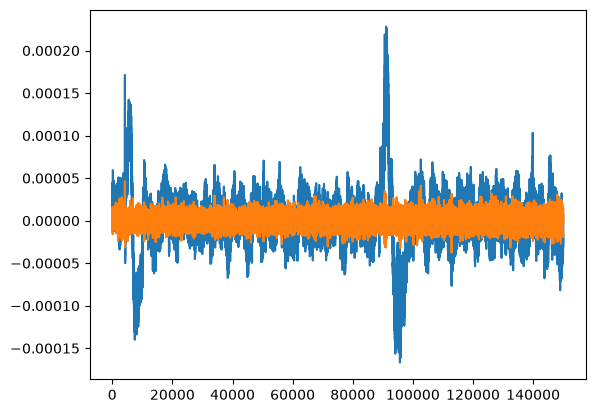

In [12]:
plt.plot(data[7])
plt.plot(data_filtered[6])  # electrode 7 is index 6


In [5]:
data.index.size

150000

In [6]:
# sampling rate is 512 Hz
vt = np.arange(data.index.size) / 512.0 # transform index in samples to time in seconds

the stimulus timing data in col. 11

Text(0.5, 0, 'time (s)')

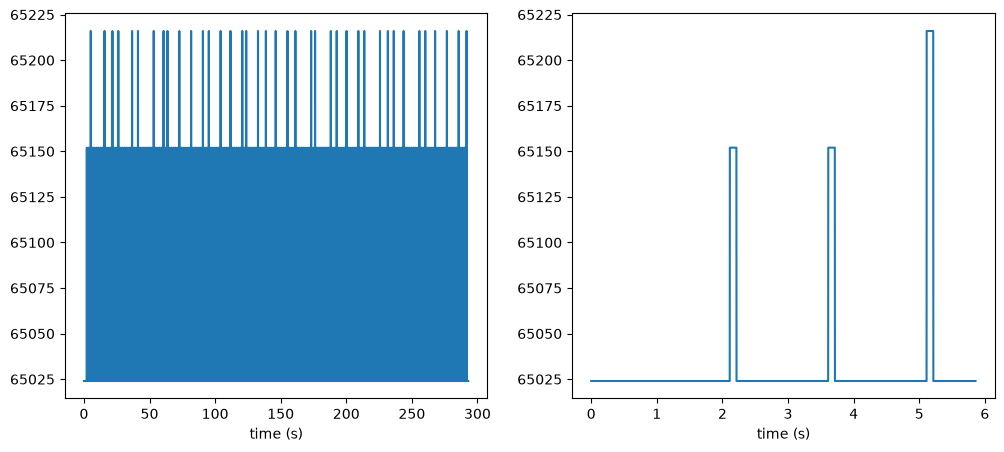

In [7]:
ts_stim = data[11]

fig, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].plot(vt, ts_stim)
axs[0].set_xlabel('time (s)')
axs[1].plot(vt[:3000], ts_stim[:3000])
axs[1].set_xlabel('time (s)')

detection of onset using the functino diff (derivative)
we extract the time when the derivative > 0

differentiate stim 1 and stim 2